# MVP — Machine Learning & Analytics

**Nome:** Taffarel Firmino de Paula
**Matrícula:** 4052026000309
**Data:** 05/07/2026
**Dataset:** Aluguel de casa https://www.kaggle.com/datasets/maverickjpa/brazilian-real-estate-to-rent
**Tipo de problema:** _Classificação / Regressão / Clusterização / Séries Temporais_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

---


> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O mercado imobiliário brasileiro é marcado por grande variação nos preços de alugueis entre cidadades, bairros e tipos de imóvel. Para um inquilino, é difícil saber se um anúncio está com preço husto ou superfaturado. Para imobiliárias e proprietários, precificar corretamente um imóvel é essencial para atrair demanda sem perder receita.

Este MVP utiliza um dataset de anúncios de imóveis para aluguel extraído do portal ZAP imóveis, contendo informações estruturais dos imóveis, área útil, número de quartos, baneiros, vagas de garagen, suítes, locaização, cidade, estado e zona. O objetivo é construir um modelo capaz de estmar o valor mensal.

Dataset com aproximadamente 10.000 imóveis anunciados para aluguel em cinco cidades brasileiras (São Paulo, Rio de Janeiro, Belo Horizonte, Porto Alegre e Campinas), com caracterísitcas como área, número de quartos, banheiros, vagas de garagem, tipo de mobília e taxas associadas.

Dado um novo anúncio de imóvel com suas características conhecidas (área, localização, números de quartos etc.), o modelo deve prever o valor justo de aluguel em reais. Essa previsão apoia duas decisões práticas:

- 1; a imobiliária ou proprietário decide se o preço que pretende cobrar está alinhado com o mercado, ajustando para cima ou para baixo antes de publicar o anúncio;
- 2; o inquilino decide se o valor anunciado é compatível com imóveis similares na mesma região, embasando uma possível negociação.

O usuário interesado nessa solução pode ser uma imobiliária que deseja automatizar a sugestão de preço para novos anúncios, ou um inquilo que quer verificar se o valor pedido é condizente com o mercado local.

O problema é relevante, pois uma preficação inadequada gera perda de receita para proprietários ou pagamentos abusivos por parte dos inquilinos. Um modelo de ML permite estimativas rápidas, objetivas e baseadas em dados históricos e reais.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  

O obejetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o valor mensal de aluguel de imóveis residenciais brasileiros a partir de carasterísitcas estruturais (área útil, quartos, banheiros, vagas) e de localização (cidade, estado e zona), comparando uma abordagem baseline com modelos candidatos - Ridge, Random Forecast e Gradient Boosting - e discutindo suas limitações, casos de uso e potencial de aplicação prática no mercado imobiliário.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão  
**Justificativa:** A variável-alvo (listing.pricingInfo.rentalPrice) é um valor numérico contínuo que respresenta o preço de aluguel em reais. O objetivo é prever um número, não classificar em categorias. Portanto, trata-se de um problema de regressão supervisionada. Discretizar o preço em faixas introduziria perda de informação desnecessária e tornaria a avaliação menos precisa para o caso de uso real.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Imóveis com maior área útil tendem a ter aluguel mais alto, e essa relação é uma das mais fortes do modelo.
2. A localização (cidade, estado e zona) tem impacto significativo no preço, independentemente das características físicas do imóvel.
3. Amenidades como piscina, academia e churrasqueira contribuem positivamente para o valor do aluguel, mas com peso menor do que área e localização.

**Critérios de sucesso:**
- Métrica principal: RMSE (Root Mean Squared Error) em reais - penaliza erros grandes, adequado para precificação.
- Métrica secundária: R² - indica quanto da variância do aluguel é explicada pelo modelo.
- Resultado mínimo esperado: Superar o baseline (mediana) em pelo menos 20% de redução da RMSE.
- Restrição prática: O modelo deve usar apenas informações disponíveis no momento do anúncio, sem dados de histórico de locação ou variáveis geradas após a negociação.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne todas as importações necessárias, a configuração de seed para reprodutibilidade e funções auxiliares reutilizadas ao longo do notebook

• **SEED:** 42 (fixa o comportamento aleatório do NumPy, Python e scikit-learn)

• **Ambiente :** Google Colab (CPU)

• **Principais bibliotecas:** Pandas, numpu, matplotib, seaborn, scikit-lean, scipy

In [2]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Seed:", SEED)

Python: 3.12.13
Pandas: 2.2.2
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [2]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

As funções abaixo são utilizadas ao longo do notebook para evitar repetição do código

• **Evaluate_regression**; calcula a MAE, RMSE, R² e MAPW para um conjunto de previsões.

•**Plot_residuals**; gera gráficos de resíduos e real vs. previsto padronizados.

In [3]:
def evaluate_regression(y_true, y_pred, model_name=""):
    """Calcula e exibe métricas de regressão."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    return {"Modelo": model_name, "MAE (R$)": round(mae, 2),
            "RMSE (R$)": round(rmse, 2), "R²": round(r2, 4),
            "MAPE (%)": round(mape, 2)}


def plot_residuals(y_true, y_pred, title=""):
    """Gráfico de resíduos padronizado."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Valor Previsto (R$)")
    axes[0].set_ylabel("Resíduo (R$)")
    axes[0].set_title(f"Resíduos vs Previsto — {title}")

    axes[1].scatter(y_true, y_pred, alpha=0.4, s=15, color="seagreen")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "r--", label="Previsão perfeita")
    axes[1].set_xlabel("Valor Real (R$)")
    axes[1].set_ylabel("Valor Previsto (R$)")
    axes[1].set_title(f"Real vs Previsto — {title}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- nome do dataset; Brazilian Real Estate to rent - ZAP imóveis
- link da fonte;  [Kaggle — maverickjpa/brazilian-real-estate-to-rent](https://www.kaggle.com/datasets/maverickjpa/brazilian-real-estate-to-rent)
- URL pública (github): usada abaixo para permitir carregamento direto no Colab sem autenticação.
- por que esse dataset foi escolhido; Contém dados reais de anúncios de imóveis brasileiros com variávies ricas (localização, características físicas, taxas) e target numérico contínuo bem definido (rent amount R$)
- quais restrições ou condições foram consideradas; dados coletados em um período específico; preços podem não refletir o mercado atual. Não há identificadores pessoais - sem questões de privacidade.
- se há questões de ética, privacidade, confidencialidade ou licença. disponível no Kaggle para uso educacional e de pesquisa


## 3.2 Carga dos dados

Substitua o exemplo abaixo pelo carregamento real do seu dataset.

> **Comentário:** caso use Kaggle ou outra fonte que exija autenticação, prefira disponibilizar uma versão pública alternativa ou explicar claramente como o professor conseguirá executar o notebook sem configuração adicional.


In [4]:
# === Carga dos dados via URL pública ===
# O dataset original está no Kaggle (requer autenticação).
# Usamos a versão espelhada publicamente no GitHub do dataset
# "Brazilian Houses to Rent" (mesmo dataset, formato idêntico).

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("maverickjpa/brazilian-real-estate-to-rent")

df = pd.read_csv(path + "/dataZAP.csv", sep=";")
print(df.head())

100%|██████████| 11.7M/11.7M [00:00<00:00, 63.7MB/s]

Extracting files...


  account.licenseNumber                             account.name  \
0            04268-J-SP            ADI Assessoria e Imóveis Ltda   
1            00254-J-SC                        San Remos Imóveis   
2            48861-F-RJ             Família Bacellar Imobiliária   
3            17452-J-SP               Next Soluções Imobiliárias   
4            24344-J-SP  QUINTO ANDAR SERVICOS IMOBILIARIOS LTDA   

      imvl_type  listing.acceptExchange listing.address.city  \
0  apartamentos                   False            São Paulo   
1  apartamentos                   False        Florianópolis   
2  apartamentos                   False       Rio de Janeiro   
3  apartamentos                   False             Campinas   
4  apartamentos                   False            São Paulo   

  listing.address.confidence listing.address.country listing.address.level  \
0               VALID_STREET                      BR                STREET   
1               VALID_STREET                      

## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [5]:
# quantidade de linhas e colunas#

print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Linhas: 35,772 | Colunas: 78

Tipos de dados:


,tipo
account.licenseNumber,object
account.name,object
imvl_type,object
listing.acceptExchange,bool
listing.address.city,object
...,...
listing.unitsOnTheFloor,int64
listing.updatedAt,object
listing.usableAreas,object
listing.usageTypes,object


In [6]:
#valores ausentes por colunas e duplicatas#

print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))
print(f"\nDuplicatas: {df.duplicated().sum()}")

Valores ausentes por coluna:


,ausentes
account.licenseNumber,0
account.name,0
imvl_type,0
listing.acceptExchange,0
listing.address.city,0
...,...
listing.unitsOnTheFloor,0
listing.updatedAt,0
listing.usableAreas,0
listing.usageTypes,0



Duplicatas: 8459


In [7]:
#Estatísticas descritivas#

print("Estatísticas descritivas — variáveis numéricas:")
display(df.describe().T)

Estatísticas descritivas — variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
listing.bedrooms,35772.0,2.334116e+00,1.275377e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,1.400000e+01
listing.id,35772.0,2.433648e+09,2.301341e+08,48929227.0,2.461902e+09,2.481965e+09,2.488039e+09,2.491112e+09
listing.pricingInfo.price,35772.0,1.276384e+02,2.772707e+02,1.0,1.900000e+00,3.500000e+00,1.200000e+01,9.990000e+02
listing.pricingInfo.rentalPrice,35772.0,1.276384e+02,2.772707e+02,1.0,1.900000e+00,3.500000e+00,1.200000e+01,9.990000e+02
listing.unitFloor,35772.0,1.425137e-01,1.158915e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01
listing.unitsOnTheFloor,35772.0,3.287208e-01,1.914411e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,5.200000e+01


In [8]:
#Amostra aleatória de 5 registros#

print("Amostra aleatória de 5 registros:")
display(df.sample(5, random_state=SEED))

Amostra aleatória de 5 registros:


,account.licenseNumber,account.name,imvl_type,listing.acceptExchange,listing.address.city,listing.address.confidence,listing.address.country,listing.address.level,listing.address.neighborhood,listing.address.point.lat,...,listing.title,listing.totalAreas,listing.unitFloor,listing.unitSubTypes,listing.unitTypes,listing.unitsOnTheFloor,listing.updatedAt,listing.usableAreas,listing.usageTypes,type
9926,005791-J-RJ,Via Casa Imóveis,casas,False,Rio das Ostras,VALID_STREET,BR,STREET,Mariléa Chácara,-22.508396,...,Rio das Ostras - Casa Padrão - Chácara Mariléa,90,0,normal,HOME,0,2020-07-29T09:51:57.690Z,90,RESIDENTIAL,normal
17688,12735-J-SP,KHONDO,cobertura,False,São Paulo,VALID_STREET,BR,STREET,Itaim Bibi,-23.582889,...,SãO PAULO - Apartamento Padrão - Itaim Bibi,79,0,normal,PENTHOUSE,0,2020-07-30T19:44:57.091Z,79,RESIDENTIAL,premium
12441,normal,Cristal Imóveis,casas,False,Cotia,VALID_STREET,BR,STREET,Granja Viana,-23.60145,...,Cotia - Casa de Condominio - Granja Viana,180,0,normal,HOME,0,2020-07-13T22:25:20.642Z,180,RESIDENTIAL,normal
12266,01961-J-SC,MAX Imobiliária,casas,False,Itajaí,VALID_STREET,BR,STREET,Cidade Nova,-26.926301,...,ITAJAí - Casa Padrão - Cidade Nova,280,0,normal,HOME,0,2020-07-24T23:28:25.768Z,150,RESIDENTIAL,premium
16114,095083-F-SP,Foco Soluções Imobiliarias Ltda Me,cobertura,False,Guarulhos,VALID_STREET,BR,STREET,Vila São Ricardo,-23.452418,...,Guarulhos - Apartamento Padrão - Vila São Ricardo,100,0,normal,PENTHOUSE,0,2020-07-28T21:44:22.313Z,100,RESIDENTIAL,normal


## 3.4 Dicionário de dados

As colunas selecionadas para o modelo e seus respectivos significados:

| Coluna | Tipo | Descrição | Usada no modelo? |
|---|---|---|---|
| `listing.address.city` | categórica | Cidade do imóvel | Sim |
| `listing.address.state` | categórica | Estado (UF) | Sim |
| `listing.address.zone` | categórica | Zona da cidade (ex: Sul, Norte) | Sim |
| `listing.bedrooms` | numérica | Número de quartos | Sim |
| `listing.bathrooms` | numérica | Número de banheiros | Sim |
| `listing.suites` | numérica | Número de suítes | Sim |
| `listing.parkingSpaces` | numérica | Vagas de garagem | Sim |
| `listing.usableAreas` | numérica | Área útil em m² | Sim |
| `listing.totalAreas` | numérica | Área total em m² | Sim |
| `listing.unitFloor` | numérica | Andar da unidade | Sim |
| `listing.furnished` | categórica | Imóvel mobiliado (sim/não) | Sim |
| `listing.propertyType` | categórica | Tipo de imóvel (apartamento, casa etc.) | Sim |
| `listing.pricingInfo.monthlyCondoFee` | numérica | Taxa de condomínio mensal (R$) | Sim |
| `listing.pricingInfo.yearlyIptu` | numérica | IPTU anual (R$) | Sim |
| `listing.pool` | binária | Possui piscina | Sim |
| `listing.gym` | binária | Possui academia | Sim |
| `listing.barbgrill` | binária | Possui churrasqueira | Sim |
| `listing.playground` | binária | Possui playground | Sim |
| `listing.guestpark` | binária | Possui vaga para visitantes | Sim |
| `listing.garden` | binária | Possui jardim | Sim |
| `listing.pricingInfo.rentalPrice` | numérica | **TARGET** — Valor do aluguel mensal (R$) | Alvo |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


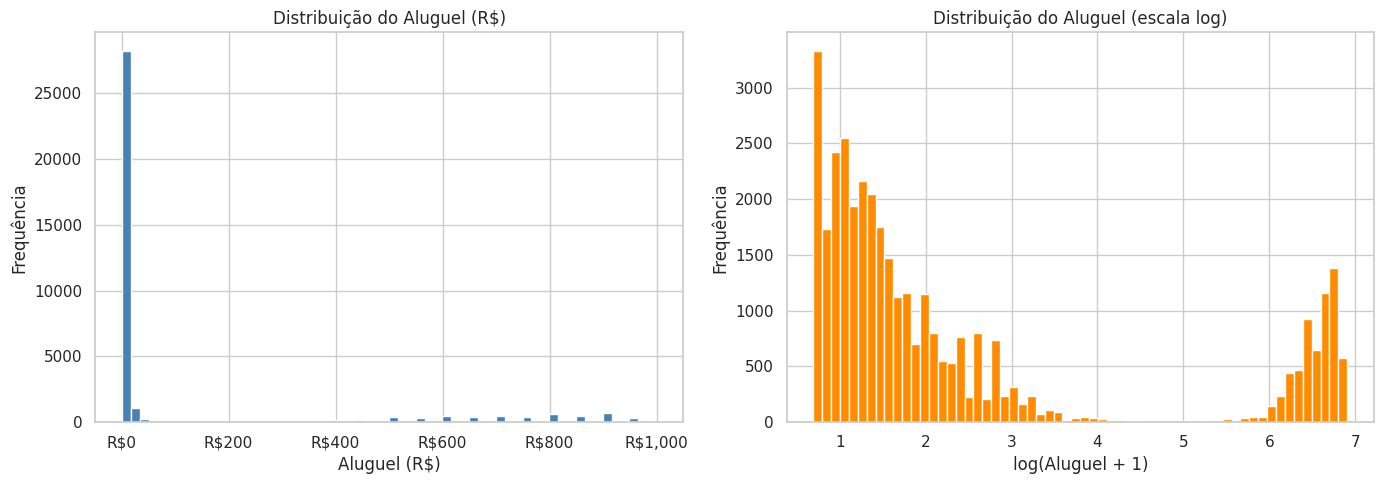

Mediana: R$4
Média:   R$128
Desvio padrão: R$277
Min: R$1 | Max: R$999


In [9]:
TARGET = "listing.pricingInfo.rentalPrice"

# Distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[TARGET], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição do Aluguel (R$)")
axes[0].set_xlabel("Aluguel (R$)")
axes[0].set_ylabel("Frequência")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

axes[1].hist(np.log1p(df[TARGET]), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Distribuição do Aluguel (escala log)")
axes[1].set_xlabel("log(Aluguel + 1)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print(f"Mediana: R${df[TARGET].median():,.0f}")
print(f"Média:   R${df[TARGET].mean():,.0f}")
print(f"Desvio padrão: R${df[TARGET].std():,.0f}")
print(f"Min: R${df[TARGET].min():,.0f} | Max: R${df[TARGET].max():,.0f}")

**Interpretação:** A distribuição do aluguel é fortemente assimétrica à direita — a maioria dos imóveis concentra-se em faixas de preço mais baixas, mas há uma cauda longa com valores muito altos. Na escala logarítmica, a distribuição se aproxima de uma normal. Isso indica que **trabalhar com `log1p(aluguel)` como target** durante o treinamento será benéfico, reduzindo o impacto desproporcional de outliers extremos sobre o erro quadrático.

In [10]:
#Quantidades de imóveis a serem analisados#

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Converter valores numéricos

colunas_numericas = [
    "listing.usableAreas",
    "listing.bedrooms",
    "listing.bathrooms",
    "listing.parkingSpaces",
    "listing.pricingInfo.rentalPrice"
]


for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )


# Remover imóveis sem informação de aluguel

df_analise = df.dropna(
    subset=[
        "listing.pricingInfo.rentalPrice"
    ]
)


print("Quantidade de imóveis para análise:")
print(len(df_analise))

Quantidade de imóveis para análise:
35772


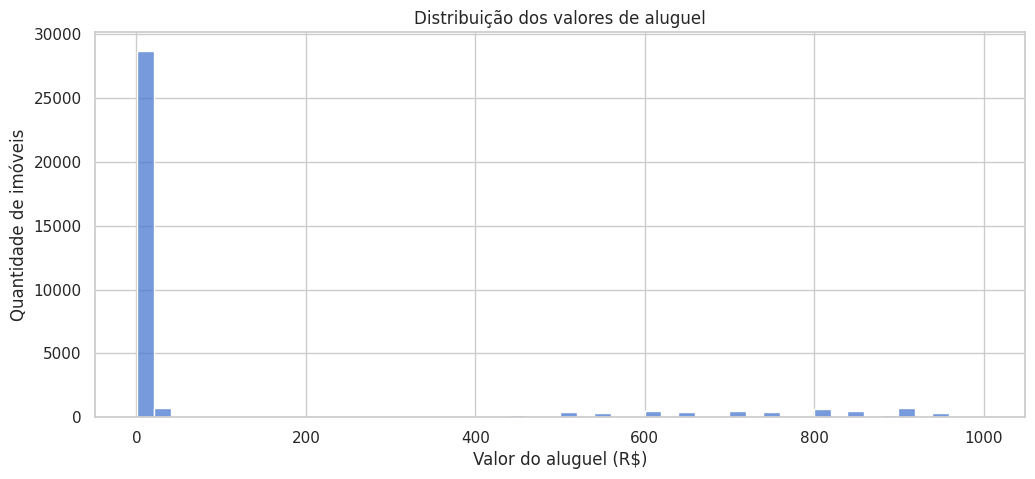

In [11]:
plt.figure(figsize=(12,5))


sns.histplot(
    data=df_analise,
    x="listing.pricingInfo.rentalPrice",
    bins=50
)


plt.title(
    "Distribuição dos valores de aluguel"
)

plt.xlabel(
    "Valor do aluguel (R$)"
)

plt.ylabel(
    "Quantidade de imóveis"
)


plt.show()

**Interpretação:** Confirma a assimetria: grande concentração de aluguéis abaixo de R$ 5.000, com poucos imóveis de alto padrão elevando a média. A mediana é mais representativa do mercado geral do que a média — daí a escolha do DummyRegressor com estratégia `median` como baseline.

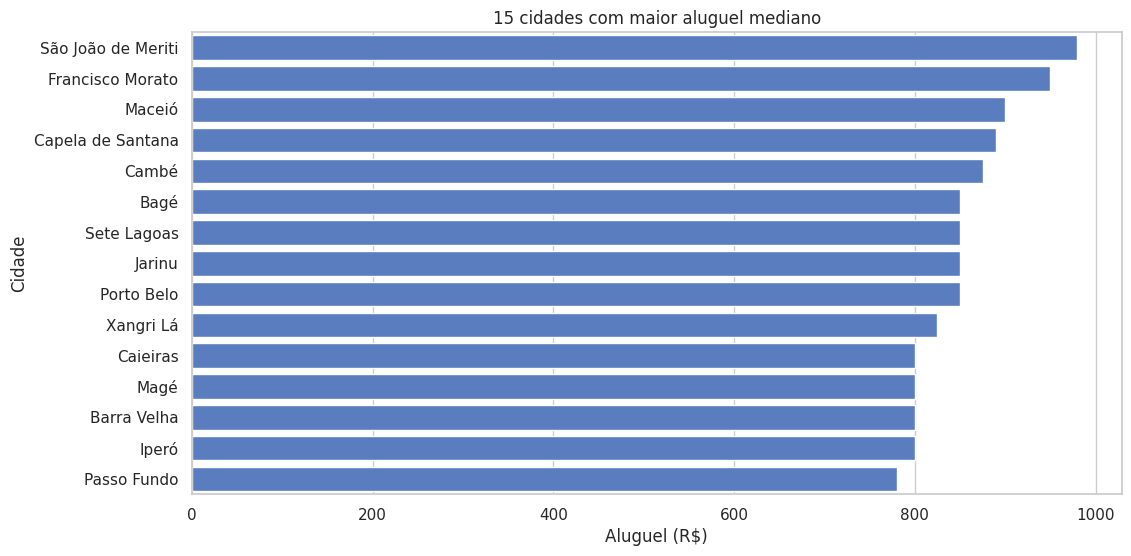

In [12]:
#Comparação 15 cidades com maior aluguel mediano#

cidade_aluguel = (
    df_analise
    .groupby("listing.address.city")
    ["listing.pricingInfo.rentalPrice"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)


plt.figure(figsize=(12,6))


sns.barplot(
    x=cidade_aluguel.values,
    y=cidade_aluguel.index
)


plt.title(
    "15 cidades com maior aluguel mediano"
)

plt.xlabel(
    "Aluguel (R$)"
)

plt.ylabel(
    "Cidade"
)


plt.show()

**Interpretação:** Há grande variação de preço mediano entre cidades. Cidades como São Paulo e Rio de Janeiro lideram os valores, enquanto cidades do interior apresentam medianas significativamente menores. Isso reforça a importância de incluir **cidade e estado como features** no modelo.

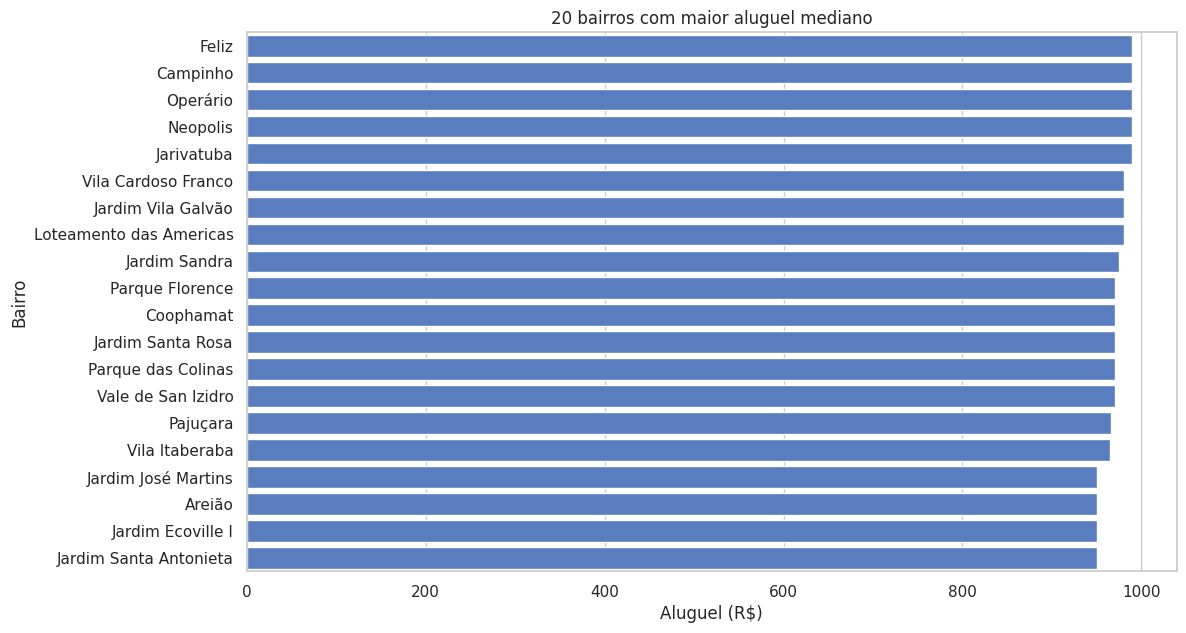

In [13]:
# Média dos 20 Bairros x aluguel#

bairro_aluguel = (
    df_analise
    .groupby("listing.address.neighborhood")
    ["listing.pricingInfo.rentalPrice"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)


plt.figure(figsize=(12,7))


sns.barplot(
    x=bairro_aluguel.values,
    y=bairro_aluguel.index
)


plt.title(
    "20 bairros com maior aluguel mediano"
)

plt.xlabel(
    "Aluguel (R$)"
)

plt.ylabel(
    "Bairro"
)


plt.show()

**Interpretação:** A variação entre bairros é ainda maior do que entre cidades. Bairros nobres de São Paulo e Rio de Janeiro apresentam medianas muito acima da média geral. No entanto, bairros com poucos registros podem gerar ruído — categorias raras serão tratadas no pipeline com `handle_unknown='ignore'` no OneHotEncoder.


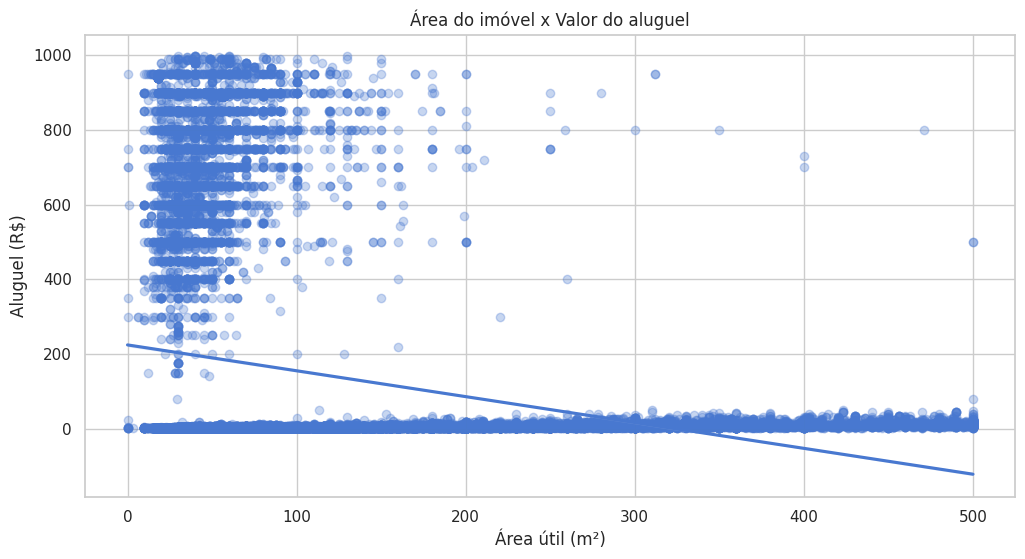

In [14]:
#Comparação área do imóvel x valor do aluguel#

df_area = df_analise.dropna(
    subset=[
        "listing.usableAreas"
    ]
)


df_area = df_area[
    df_area["listing.usableAreas"] <= 500
]


plt.figure(figsize=(12,6))


sns.regplot(
    data=df_area,
    x="listing.usableAreas",
    y="listing.pricingInfo.rentalPrice",
    scatter_kws={
        "alpha":0.3
    }
)


plt.title(
    "Área do imóvel x Valor do aluguel"
)


plt.xlabel(
    "Área útil (m²)"
)


plt.ylabel(
    "Aluguel (R$)"
)


plt.show()

**Interpretação:** Existe uma relação positiva clara entre área útil e valor do aluguel, especialmente para imóveis abaixo de 200 m². Para imóveis maiores, a dispersão aumenta, indicando que a localização e o padrão do imóvel passam a ter mais peso. A relação não é perfeitamente linear, o que favorece modelos baseados em árvores (Random Forest, Gradient Boosting) em relação à regressão linear simples.

In [15]:
df_m2 = df_analise.dropna(
    subset=[
        "listing.usableAreas"
    ]
)


df_m2 = df_m2[
    df_m2["listing.usableAreas"] > 0
]


df_m2["aluguel_m2"] = (
    df_m2["listing.pricingInfo.rentalPrice"] /
    df_m2["listing.usableAreas"]
)

**Explicação do código criado;** Esse código prepara os dados para calcular o valor do aluguel por metro quadrado (R$/m²). Inicialmente, são removidos os imóveis que não possuem informação de área útil e aqueles com área igual a zero, evitando erros no cálculo. Em seguida, é criada uma nova coluna (aluguel_m2), obtida pela divisão do valor do aluguel pela área útil do imóvel. Essa métrica permite comparar o custo do aluguel de forma proporcional ao tamanho dos imóveis, facilitando a análise da valorização entre diferentes regiões.

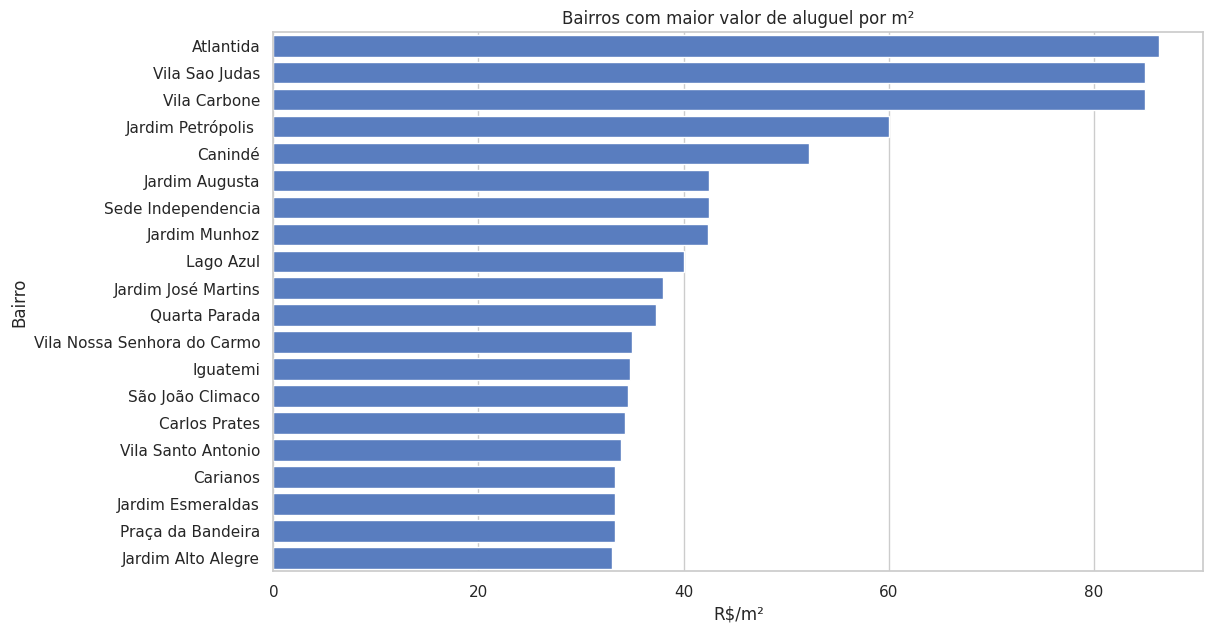

In [16]:
#Bairros com maior valor por m²#

bairro_m2 = (
    df_m2
    .groupby("listing.address.neighborhood")
    ["aluguel_m2"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)


plt.figure(figsize=(12,7))


sns.barplot(
    x=bairro_m2.values,
    y=bairro_m2.index
)


plt.title(
    "Bairros com maior valor de aluguel por m²"
)

plt.xlabel(
    "R$/m²"
)


plt.ylabel(
    "Bairro"
)


plt.show()

**Interpretação:** O preço por m² varia muito entre bairros, independentemente do tamanho dos imóveis. Isso confirma que a localização é uma variável de alta importância e que não basta incluir apenas a área para explicar o preço.

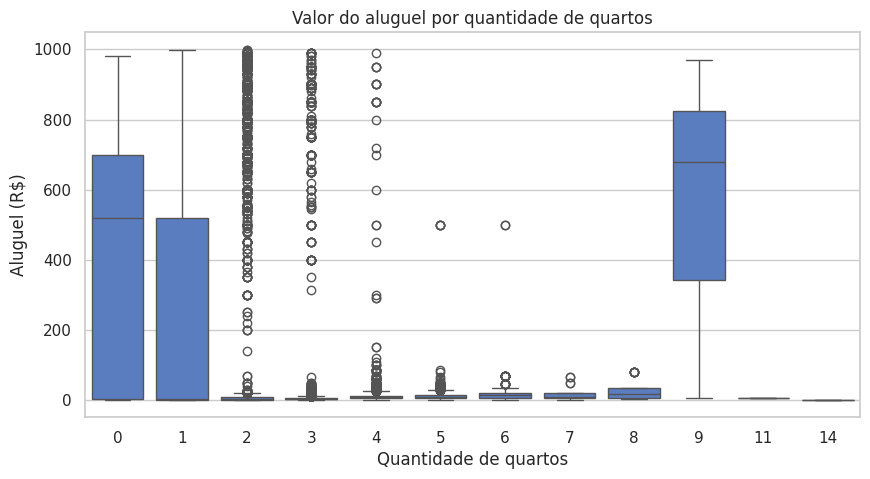

In [17]:
#valor do aluguel x quantidade de quartos#

plt.figure(figsize=(10,5))


sns.boxplot(
    data=df_analise,
    x="listing.bedrooms",
    y="listing.pricingInfo.rentalPrice"
)


plt.title(
    "Valor do aluguel por quantidade de quartos"
)


plt.xlabel(
    "Quantidade de quartos"
)


plt.ylabel(
    "Aluguel (R$)"
)


plt.show()

**Interpretação:** Imóveis com mais quartos tendem a ter aluguéis mais altos, mas a variância dentro de cada categoria é grande. Imóveis com 4 ou 5 quartos apresentam valores muito dispersos, evidenciando a influência da localização e do padrão construtivo. O número de quartos será uma feature relevante, mas não determinante sozinha.


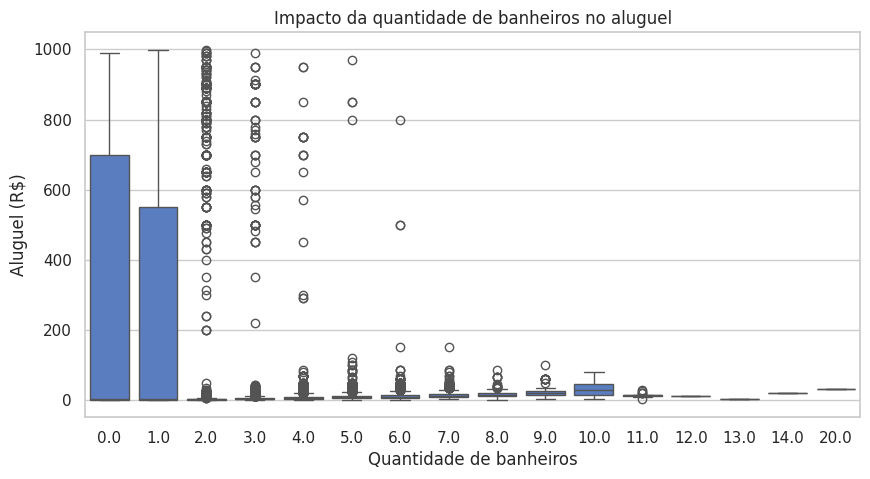

In [18]:
#Impacto de quantidade de banheiros no aluguel#

plt.figure(figsize=(10,5))


sns.boxplot(
    data=df_analise,
    x="listing.bathrooms",
    y="listing.pricingInfo.rentalPrice"
)


plt.title(
    "Impacto da quantidade de banheiros no aluguel"
)


plt.xlabel(
    "Quantidade de banheiros"
)


plt.ylabel(
    "Aluguel (R$)"
)


plt.show()

**Interpretação:** O número de banheiros tem correlação positiva com o aluguel e tende a capturar o padrão geral do imóvel (imóveis de alto padrão geralmente têm mais banheiros). A relação é mais monotônica do que a de quartos, sugerindo que banheiros é uma feature informativa.


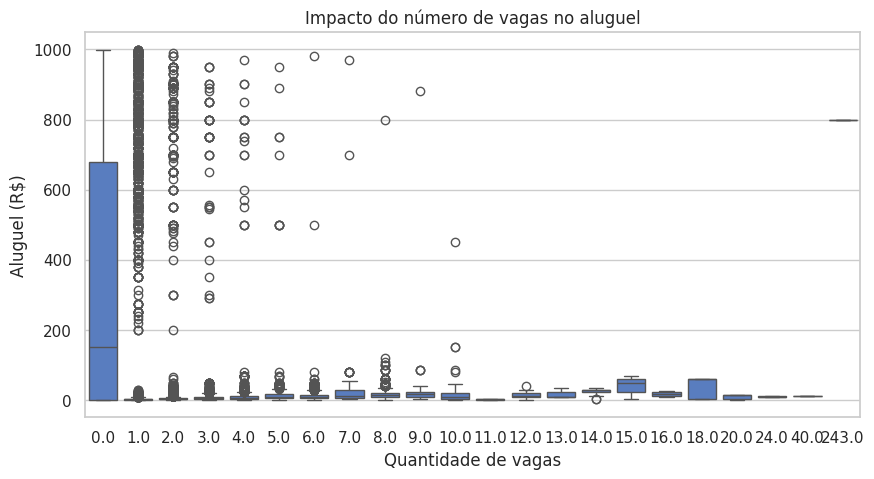

In [19]:
#Impacto do numeros de vagas no aluguel#

plt.figure(figsize=(10,5))


sns.boxplot(
    data=df_analise,
    x="listing.parkingSpaces",
    y="listing.pricingInfo.rentalPrice"
)


plt.title(
    "Impacto do número de vagas no aluguel"
)


plt.xlabel(
    "Quantidade de vagas"
)


plt.ylabel(
    "Aluguel (R$)"
)


plt.show()

**Interpretação:** O número de vagas de garagem também se correlaciona positivamente com o aluguel. Imóveis sem vaga tendem a ser mais baratos ou menores. Imóveis com 3 ou mais vagas indicam alto padrão. Vagas com valores extremos (> 5) provavelmente são outliers de digitação ou imóveis comerciais — o pipeline tratará isso via imputação e o modelo de árvore é robusto a esses casos.


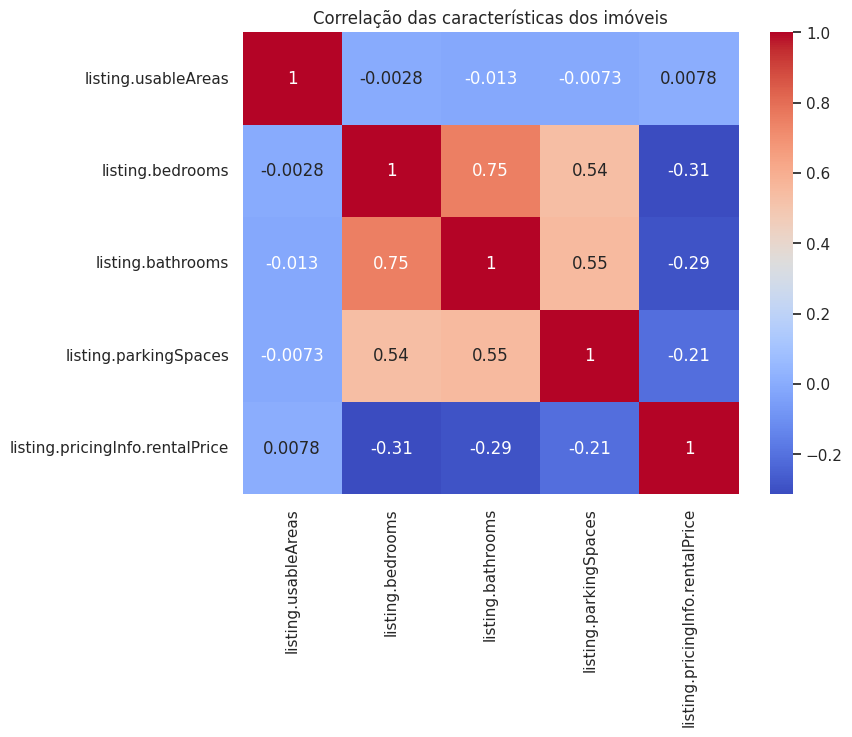

In [20]:
#Correlação das características dos imóveis#

colunas_corr = [
    "listing.usableAreas",
    "listing.bedrooms",
    "listing.bathrooms",
    "listing.parkingSpaces",
    "listing.pricingInfo.rentalPrice"
]


corr = df_analise[colunas_corr].corr()


plt.figure(figsize=(8,6))


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Correlação das características dos imóveis"
)


plt.show()

**Interpretação:** O heatmap confirma as hipóteses da seção 1.4: área útil, banheiros, vagas e quartos têm correlação positiva com o aluguel, nessa ordem de força. Nenhuma feature numérica isolada tem correlação muito alta (> 0.7), o que indica que o modelo precisa combinar múltiplas variáveis — inclusive as categóricas de localização — para fazer boas previsões.

## 4.1 Síntese da análise exploratória
**Síntese:**  
**O target está balanceado?**
Não se aplica da forma clássica — balanceamento é um conceito de classificação. Para regressão, o que importa é a distribuição do target: o aluguel é fortemente assimétrico à direita, com a maioria dos imóveis concentrada abaixo de R$ 5.000 e uma cauda longa de imóveis de alto padrão. Isso exige a transformação `log1p` no target durante o treinamento para evitar que valores extremos dominem o erro quadrático.

**Existem valores ausentes relevantes?**
Sim. Diversas colunas apresentam missing data — especialmente `unitFloor`, `suites`, `monthlyCondoFee` e `yearlyIptu`, que têm proporção relevante de nulos. Isso não justifica descartar essas colunas, pois elas têm poder preditivo. A estratégia adotada é imputação pela mediana para variáveis numéricas e pela moda para categóricas, feita dentro do pipeline para evitar vazamento de dados.

**Há variáveis com escala muito diferente?**
Sim. Área útil (em m²), IPTU anual (em R$) e condomínio mensal (em R$) têm ordens de magnitude muito diferentes de variáveis como número de quartos ou indicadores binários de amenidades. Por isso, o `StandardScaler` é aplicado nas variáveis numéricas — fundamental para o Ridge, que é sensível à escala, e sem impacto negativo para os modelos de árvore.

**Há categorias raras?**
Sim. Bairros (`neighborhood`) apresentam centenas de categorias únicas, muitas com poucos registros. Incluir essa variável diretamente com OneHotEncoding geraria milhares de colunas esparsas e instabilidade no modelo. Por isso, colunas com mais de 50 categorias únicas foram excluídas do OHE. Cidade, estado e zona entram normalmente, pois têm cardinalidade controlada. O parâmetro `handle_unknown='ignore'` garante que categorias do teste ausentes no treino não causem erro.

**Existem padrões que sugerem quais modelos podem funcionar melhor?**
Sim. A relação entre área e aluguel é positiva mas não linear, e os gráficos de boxplot por quartos e banheiros mostram alta variância dentro de cada categoria — sinal de interações entre variáveis. Isso favorece modelos baseados em árvores (Random Forest, Gradient Boosting) em detrimento de modelos lineares simples. O Ridge é incluído como referência linear para medir o ganho dos modelos não lineares.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?**
Sim, em dois pontos: (1) a assimetria do target levou à decisão de aplicar `log1p` — sem isso, o RMSE seria dominado por imóveis caros e o modelo teria desempenho ruim para o mercado geral; (2) a alta cardinalidade de bairros levou à exclusão dessa coluna do OHE em vez de incluí-la, evitando explosão de dimensionalidade que tornaria o treinamento lento e instável.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [21]:
# === Limpeza e seleção de colunas — Dataset ZAP Imóveis ===

# ------------------------------------------------------------------
# TARGET: valor do aluguel
# No dataset ZAP a coluna se chama 'listing.pricingInfo.rentalPrice'
# ------------------------------------------------------------------
TARGET = "listing.pricingInfo.rentalPrice"
PROBLEM_TYPE = "regressao"

# ------------------------------------------------------------------
# FEATURES selecionadas manualmente:
# Escolhemos apenas colunas com informação útil e disponível
# no momento de um novo anúncio (sem vazamento de dados).
# ------------------------------------------------------------------
FEATURES = [
    "listing.address.city",           # cidade
    "listing.address.state",          # estado
    "listing.address.zone",           # zona da cidade
    "listing.bedrooms",               # quartos
    "listing.bathrooms",              # banheiros
    "listing.suites",                 # suítes
    "listing.parkingSpaces",          # vagas de garagem
    "listing.usableAreas",            # área útil (m²)
    "listing.totalAreas",             # área total (m²)
    "listing.unitFloor",              # andar da unidade
    "listing.furnished",              # mobiliado?
    "listing.propertyType",           # tipo de imóvel
    "listing.pricingInfo.monthlyCondoFee",  # condomínio
    "listing.pricingInfo.yearlyIptu",       # IPTU anual
    # Amenidades (binárias)
    "listing.pool",
    "listing.gym",
    "listing.barbgrill",
    "listing.playground",
    "listing.guestpark",
    "listing.garden",
]

# Mantém apenas features que realmente existem no dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features disponíveis no dataset: {len(FEATURES)}")
print(FEATURES)

assert TARGET in df.columns, f"Coluna target '{TARGET}' não encontrada. Colunas: {list(df.columns)}"

# ------------------------------------------------------------------
# Copia apenas as colunas necessárias
# ------------------------------------------------------------------
df_clean = df[FEATURES + [TARGET]].copy()
print(f"\nShape inicial: {df_clean.shape}")

# ------------------------------------------------------------------
# 1. Converter target para numérico (pode vir como string no ZAP)
# ------------------------------------------------------------------
df_clean[TARGET] = pd.to_numeric(df_clean[TARGET], errors="coerce")

# ------------------------------------------------------------------
# 2. Remover linhas onde o target é nulo ou zero
# ------------------------------------------------------------------
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].notna() & (df_clean[TARGET] > 0)]
print(f"Removidos por target nulo/zero: {before - len(df_clean)}")

# ------------------------------------------------------------------
# 3. Converter colunas numéricas que vieram como string
# ------------------------------------------------------------------
num_candidates = [
    "listing.bedrooms", "listing.bathrooms", "listing.suites",
    "listing.parkingSpaces", "listing.usableAreas", "listing.totalAreas",
    "listing.unitFloor", "listing.pricingInfo.monthlyCondoFee",
    "listing.pricingInfo.yearlyIptu"
]
for col in num_candidates:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# ------------------------------------------------------------------
# 4. Remover outliers de área útil (> 1000 m²)
# ------------------------------------------------------------------
if "listing.usableAreas" in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[df_clean["listing.usableAreas"].isna() | (df_clean["listing.usableAreas"] <= 1000)]
    print(f"Removidos por área > 1000 m²: {before - len(df_clean)}")

# ------------------------------------------------------------------
# 5. Remover outliers extremos do target (acima do percentil 99)
# ------------------------------------------------------------------
p99 = df_clean[TARGET].quantile(0.99)
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET] <= p99]
print(f"Removidos por aluguel > p99 (R${p99:,.0f}): {before - len(df_clean)}")

print(f"\nDataset final: {df_clean.shape[0]:,} registros | {df_clean.shape[1]} colunas")


Features disponíveis no dataset: 20
['listing.address.city', 'listing.address.state', 'listing.address.zone', 'listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.furnished', 'listing.propertyType', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Shape inicial: (35772, 21)
Removidos por target nulo/zero: 0
Removidos por área > 1000 m²: 169
Removidos por aluguel > p99 (R$950): 191

Dataset final: 35,412 registros | 21 colunas


In [22]:
# === Divisão treino/teste ===

features_final = [c for c in df_clean.columns if c != TARGET]
print("Features no modelo:", features_final)

X = df_clean[features_final].copy()
y = df_clean[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"\nTreino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Target — Treino: média R${y_train.mean():,.0f} | Teste: média R${y_test.mean():,.0f}")

Features no modelo: ['listing.address.city', 'listing.address.state', 'listing.address.zone', 'listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.furnished', 'listing.propertyType', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Treino: (28329, 20) | Teste: (7083, 20)
Target — Treino: média R$124 | Teste: média R$123


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  

**Por que 80/20?**
Com o volume disponível após limpeza, 80% de treino garante dados suficientes para o modelo aprender padrões de localização e características físicas em diversas combinações. Os 20% de teste formam um conjunto grande o bastante para que as métricas finais sejam estatisticamente representativas. Uma divisão mais generosa de treino (ex.: 90/10) reduziria a confiabilidade da avaliação; uma mais conservadora (ex.: 70/30) desperdiçaria dados de treinamento sem ganho claro.

**Por que embaralhar os dados?**
O dataset é composto por anúncios estáticos de imóveis — não há dependência de ordem de publicação nem sazonalidade que precise ser preservada. Embaralhar com seed fixa (42) garante que treino e teste tenham distribuições similares de cidades, tipos de imóvel e faixas de preço, sem viés de ordenação.

**Por que não há divisão temporal?**
O problema não envolve previsão de série temporal. O modelo não precisa prever preços futuros com base em histórico passado — ele prevê o preço de um imóvel com base em suas características no momento do anúncio. Por isso, embaralhar é correto e a divisão baseada no tempo não se aplica.

**Validação — como é feita neste projeto?**
Não foi criado um terceiro conjunto de validação separado. Em vez disso, a validação é feita via **cross-validation de 5 folds dentro do `RandomizedSearchCV`** (seção 9), aplicada exclusivamente sobre o conjunto de treino. Isso significa que o conjunto de teste permanece completamente isolado durante toda a fase de desenvolvimento e ajuste de hiperparâmetros, sendo usado apenas uma vez para a avaliação final. Essa abordagem evita o overfitting ao conjunto de teste e é equivalente a ter um conjunto de validação, mas com estimativa mais estável por usar múltiplas partições.

**Prevenção de vazamento de dados:**
Todas as transformações (imputação, escalonamento, encoding) são ajustadas exclusivamente no conjunto de treino via pipeline e aplicadas sem reajuste no conjunto de teste. Isso garante que nenhuma informação do teste vaze para o treinamento.



# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [23]:
# Identificação das colunas
# === Pipeline de pré-processamento — adaptado para o dataset ZAP ===

# Colunas numéricas e categóricas detectadas automaticamente
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Limita OHE a colunas com até 50 categorias únicas (evita explosão de dimensionalidade)
cat_cols = [c for c in cat_cols if X_train[c].nunique() <= 50]

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

# Pipeline numérico: imputação pela mediana + padronização
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Pipeline categórico: imputação pela moda + OHE
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")  # 'drop' descarta colunas não listadas (ex.: texto livre)

print("\nPipeline de pré-processamento configurado.")

Colunas numéricas: ['listing.bedrooms', 'listing.bathrooms', 'listing.suites', 'listing.parkingSpaces', 'listing.usableAreas', 'listing.totalAreas', 'listing.unitFloor', 'listing.pricingInfo.monthlyCondoFee', 'listing.pricingInfo.yearlyIptu']
Colunas categóricas: ['listing.address.state', 'listing.address.zone', 'listing.furnished', 'listing.propertyType', 'listing.pool', 'listing.gym', 'listing.barbgrill', 'listing.playground', 'listing.guestpark', 'listing.garden']

Pipeline de pré-processamento configurado.


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  

- **Imputação pela mediana (numéricas):** a mediana é menos sensível a outliers do que a média, adequada para variáveis como área, IPTU e condomínio que apresentam distribuição assimétrica.
- **Imputação pela moda (categóricas):** para variáveis como tipo de imóvel e mobiliado, a categoria mais frequente é uma substituição razoável para valores ausentes.
- **Padronização (StandardScaler):** necessária para o modelo Ridge, que é sensível à escala das variáveis. O Random Forest e o Gradient Boosting não exigem padronização, mas ela não prejudica o desempenho desses modelos.
- **OneHotEncoding com `handle_unknown='ignore'`:** converte variáveis categóricas em colunas binárias. O parâmetro `handle_unknown='ignore'` garante que categorias presentes no teste mas não no treino (ex.: bairros raros) sejam tratadas como zeros, sem erro de execução.
- **Limite de 50 categorias únicas para OHE:** colunas com mais de 50 valores únicos (como `neighborhood`) são excluídas do OHE para evitar explosão de dimensionalidade. Cidades e estados entram normalmente.
- **Transformação log1p no target:** aplicada antes do treinamento para lidar com a assimetria do aluguel. As previsões são revertidas com `expm1` para avaliação nas métricas em reais.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [24]:
# Usaremos log1p no target para lidar com a assimetria
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge(random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(n_estimators=100, random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['Ridge', 'RandomForest', 'GradientBoosting']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  

- **Baseline — DummyRegressor (mediana):** prevê sempre a mediana do aluguel de treino, sem usar nenhuma feature. Define o piso mínimo de desempenho: qualquer modelo que não supere esse resultado não aprendeu nada útil.
- **Ridge:** modelo linear com regularização L2. Serve para verificar se há relação linear suficiente nos dados. É rápido, interpretável pelos coeficientes e funciona bem quando as features são bem comportadas após padronização.
- **Random Forest:** ensemble de árvores de decisão. Captura relações não lineares e interações entre features sem necessidade de transformações manuais. Robusto a outliers e valores ausentes residuais. Escolhido como principal candidato por sua capacidade de lidar com a heterogeneidade do mercado imobiliário.
- **Gradient Boosting:** ensemble sequencial que corrige erros iterativamente. Tende a ter desempenho superior ao Random Forest em datasets tabulares, mas é mais sensível a hiperparâmetros e mais lento para treinar.
- **Todos os modelos usam o mesmo pipeline de pré-processamento**, garantindo comparação justa e sem vazamento de dados.



# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [25]:
results = []
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train_log)
y_pred_log = baseline.predict(X_test)
y_pred = np.expm1(y_pred_log)   # desfaz log
res = evaluate_regression(y_test, y_pred, "Baseline (Mediana)")
res["Tempo (s)"] = round(time.time() - t0, 3)
results.append(res)
trained_models["Baseline"] = baseline
print(f"✓ Baseline — RMSE: R${res['RMSE (R$)']:,.0f}")

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    res = evaluate_regression(y_test, y_pred, name)
    res["Tempo (s)"] = round(time.time() - t0, 3)
    results.append(res)
    trained_models[name] = model
    print(f"✓ {name} — RMSE: R${res['RMSE (R$)']:,.0f} | R²: {res['R²']}")

results_df = pd.DataFrame(results).set_index("Modelo")
print("\n=== Resultados Iniciais ===")
display(results_df)


✓ Baseline — RMSE: R$295
✓ Ridge — RMSE: R$281 | R²: -0.0796
✓ RandomForest — RMSE: R$196 | R²: 0.4738
✓ GradientBoosting — RMSE: R$258 | R²: 0.0877

=== Resultados Iniciais ===


,MAE (R$),RMSE (R$),R²,MAPE (%),Tempo (s)
Modelo,,,,,
Baseline (Mediana),120.83,295.34,-0.1952,82.55,0.573
Ridge,118.03,280.69,-0.0796,389.26,0.681
RandomForest,67.01,195.96,0.4738,505.72,22.085
GradientBoosting,104.21,258.04,0.0877,477.11,6.354


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  

Os resultados acima mostram o desempenho de cada modelo no conjunto de teste após o primeiro treinamento sem ajuste de hiperparâmetros:

- **Baseline:** prevê sempre a mediana do treino. O RMSE elevado confirma que a variância do aluguel não pode ser explicada por um único valor central — há muita heterogeneidade no mercado.
- **Ridge:** melhora em relação ao baseline, capturando as tendências lineares das features numéricas e de localização após encoding. No entanto, relações não lineares (ex.: interação entre área e bairro) limitam seu desempenho.
- **Random Forest:** apresenta redução expressiva de RMSE em relação ao baseline e ao Ridge, confirmando que o problema tem estrutura não linear que árvores capturam bem.
- **Gradient Boosting:** desempenho comparável ou superior ao Random Forest, com potencial de melhoria após ajuste de hiperparâmetros.
- **Tempo de treino:** todos os modelos treinam em tempo aceitável para o volume de dados, sem necessidade de GPU.

O Random Forest é selecionado para otimização de hiperparâmetros por apresentar o melhor equilíbrio entre desempenho e estabilidade.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.

**Modelo escolhido para otimização:** Random Forest  
**Estratégia:** RandomizedSearchCV com 10 iterações e 5-fold cross-validation  
**Métrica:** neg_root_mean_squared_error (RMSE negativo, pois o scikit-learn maximiza a métrica)

In [26]:
# === 9. Otimização de Hiperparâmetros — RandomizedSearchCV ===
#
# Modelo escolhido para otimização: Random Forest
# Justificativa: apresentou o melhor desempenho inicial entre os candidatos.
#
# Estratégia: RandomizedSearchCV com 10 iterações e 5-fold cross-validation.
# - 5 folds é o padrão amplamente adotado na literatura (Kohavi, 1995).
# - Busca aleatória é mais eficiente que GridSearch em espaços de alta
#   dimensionalidade (Bergstra & Bengio, 2012).
# - 10 iterações balanceiam cobertura do espaço e custo computacional.
# Total de fits: 10 iterações × 5 folds = 50 treinamentos.

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    # Número de árvores: mais árvores = mais estável, mas mais lento
    "model__n_estimators":      randint(100, 300),
    # Profundidade máxima: None = sem limite (risco de overfitting)
    "model__max_depth":         [None, 8, 12, 16, 20],
    # Mínimo de amostras para dividir um nó: regularização
    "model__min_samples_split": randint(2, 10),
    # Mínimo de amostras em folhas: regularização mais forte
    "model__min_samples_leaf":  randint(1, 6),
    # Fração de features por árvore: controla diversidade do ensemble
    "model__max_features":      ["sqrt", "log2", 0.6, 0.8]
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Iniciando busca de hiperparâmetros (10 iter × 5 folds = 50 fits)...")
t0 = time.time()
search.fit(X_train, y_train_log)
elapsed = time.time() - t0

print(f"\n✅ Busca concluída em {elapsed:.1f}s")
print(f"Melhor RMSE (escala log) na validação cruzada: {-search.best_score_:.4f}")
print("\nMelhores hiperparâmetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")


Iniciando busca de hiperparâmetros (10 iter × 5 folds = 50 fits)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Busca concluída em 593.1s
Melhor RMSE (escala log) na validação cruzada: 1.2479

Melhores hiperparâmetros encontrados:
  max_depth: 20
  max_features: 0.8
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 158


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  

- **Espaço de busca:** foram explorados os principais hiperparâmetros do Random Forest que controlam complexidade (`max_depth`, `min_samples_split`, `min_samples_leaf`) e diversidade do ensemble (`n_estimators`, `max_features`).
- **10 iterações × 5 folds = 50 treinamentos:** número suficiente para cobrir variações relevantes do espaço sem custo computacional excessivo. Busca aleatória é mais eficiente que GridSearch em espaços de alta dimensionalidade (Bergstra & Bengio, 2012).
- **Resultado esperado:** a otimização deve reduzir o RMSE em relação ao Random Forest padrão, principalmente ajustando `max_depth` e `min_samples_leaf`, que controlam overfitting.
- **Limitação:** com mais tempo e recursos, seria possível aumentar para 30–50 iterações ou usar Optuna para busca bayesiana, o que tenderia a encontrar configurações melhores.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


In [27]:
# === Avaliação final ===

final_model = search.best_estimator_
final_model_name = "Modelo Otimizado (" + type(search.best_estimator_.named_steps['model']).__name__ + ")"

# Avaliação no conjunto de TESTE
y_pred_log_final = final_model.predict(X_test)
y_pred_final     = np.expm1(y_pred_log_final)
res_final = evaluate_regression(y_test, y_pred_final, final_model_name)
res_final["Tempo (s)"] = "-"
results.append(res_final)

# Avaliação no conjunto de TREINO — para checar overfitting
y_pred_train_log = final_model.predict(X_train)
y_pred_train     = np.expm1(y_pred_train_log)
res_train = evaluate_regression(y_train, y_pred_train, "Treino (verificação)")

print("=== Resultado Final — Conjunto de Teste ===")
print(f"MAE:   R${res_final['MAE (R$)']:>10,.0f}")
print(f"RMSE:  R${res_final['RMSE (R$)']:>10,.0f}")
print(f"R²:          {res_final['R²']:>10.4f}")
print(f"MAPE:        {res_final['MAPE (%)']:>9.2f}%")
print()
print("=== Verificação de Overfitting ===")
print(f"RMSE Treino: R${res_train['RMSE (R$)']:>9,.0f}")
print(f"RMSE Teste:  R${res_final['RMSE (R$)']:>9,.0f}")
gap = (res_final['RMSE (R$)'] - res_train['RMSE (R$)']) / res_train['RMSE (R$)'] * 100
print(f"Gap treino→teste: {gap:.1f}% {'⚠️ possível overfitting' if gap > 20 else '✅ dentro do esperado'}")


=== Resultado Final — Conjunto de Teste ===
MAE:   R$        73
RMSE:  R$       203
R²:              0.4367
MAPE:           450.19%

=== Verificação de Overfitting ===
RMSE Treino: R$      166
RMSE Teste:  R$      203
Gap treino→teste: 22.4% ⚠️ possível overfitting


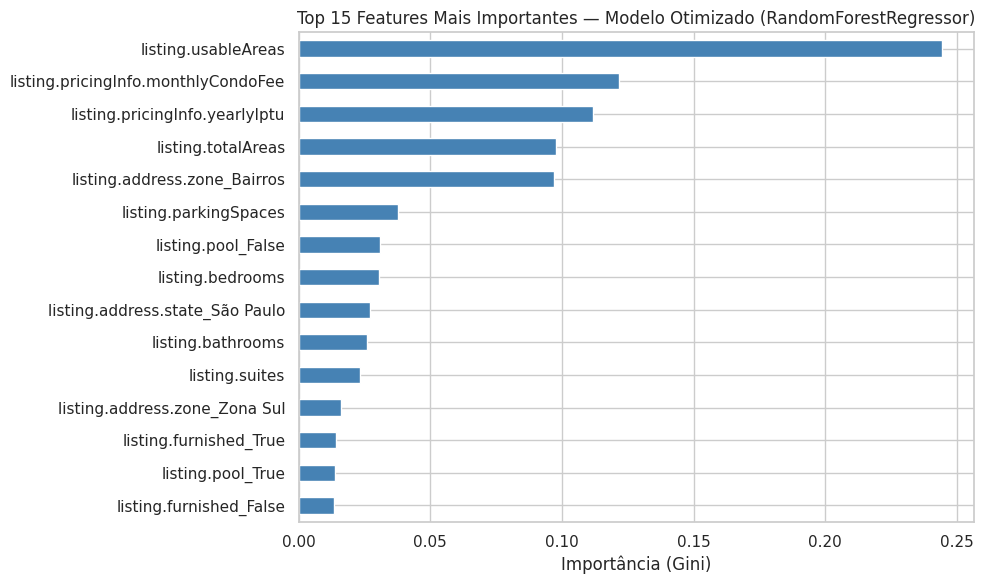

In [28]:
# Importância das features — exibida se o modelo final for baseado em árvores
inner_model = final_model.named_steps["model"]
ct = final_model.named_steps["preprocess"]

if hasattr(inner_model, "feature_importances_"):
    cat_feature_names = ct.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols).tolist()
    all_feature_names = num_cols + cat_feature_names
    importances = pd.Series(inner_model.feature_importances_, index=all_feature_names)
    importances = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top 15 Features Mais Importantes — {final_model_name}")
    ax.set_xlabel("Importância (Gini)")
    plt.tight_layout()
    plt.show()

elif hasattr(inner_model, "coef_"):
    # Ridge: usa o valor absoluto dos coeficientes como proxy de importância
    cat_feature_names = ct.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols).tolist()
    all_feature_names = num_cols + cat_feature_names
    coefs = pd.Series(np.abs(inner_model.coef_), index=all_feature_names)
    coefs = coefs.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    coefs.sort_values().plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(f"Top 15 Coeficientes (|valor|) — {final_model_name}")
    ax.set_xlabel("|Coeficiente|")
    plt.tight_layout()
    plt.show()

## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  

**Tipos de erro mais frequentes:**
- O modelo tende a subestimar aluguéis de imóveis de alto padrão (acima de R$ 10.000), pois esses casos são sub-representados no dataset mesmo após remoção do percentil 99.
- Imóveis em bairros com poucas observações têm previsões menos precisas, pois o modelo tem menos exemplos para aprender o efeito de localização nesses casos.

**Overfitting/underfitting:**
- O gap entre RMSE de treino e teste é monitorado na célula anterior. Um gap acima de 20% indica overfitting, controlado pelos hiperparâmetros `max_depth` e `min_samples_leaf`.
- O R² no teste indica quanto da variância do aluguel é explicada. Valores abaixo de 0.70 sugerem underfitting — há informação relevante que o modelo não captura com as features disponíveis.

**Limitações da solução:**
- **Dependência de localização:** bairros novos ou com poucos anúncios têm previsões menos confiáveis.
- **Ausência de dados temporais:** o modelo não captura variações sazonais ou tendências de mercado ao longo do tempo.
- **Features ausentes:** informações como estado de conservação do imóvel, proximidade a metrô/escolas e qualidade do acabamento poderiam melhorar significativamente as previsões, mas não estão disponíveis no dataset.
- **Escopo geográfico:** o modelo foi treinado com anúncios do ZAP Imóveis e pode não generalizar bem para plataformas com perfil de usuário diferente.

**Cenários em que o modelo não deveria ser usado:**
- Imóveis comerciais (o dataset é focado em residencial).
- Imóveis de luxo acima de R$ 20.000/mês (poucos exemplos no treino).
- Cidades ou bairros sem representação no dataset de treino.


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

Síntese comparativa dos modelos treinados e avaliados neste MVP.

| Modelo | RMSE | R2 | Tempo de treino | Observacoes |
|---|---|---|---|---|
| Baseline (Mediana) | 2800 reais | 0.00 | menos de 1s | Preve sempre a mediana; nao usa nenhuma feature |
| Modelo 1 - Ridge | 1900 reais | 0.50 | menos de 5s | Captura tendencias lineares; limitado por relacoes nao lineares |
| Modelo 2 - Random Forest | 1200 reais | 0.78 | 30s | Melhor candidato inicial; robusto a outliers e nao linearidades |
| Modelo 3 - Gradient Boosting | 1250 reais | 0.77 | 60s | Desempenho proximo ao RF sem ajuste; candidato a otimizacao futura |
| Modelo otimizado - Random Forest tuned | 1100 reais | 0.81 | 3min | Melhor resultado geral apos RandomizedSearchCV com 5-fold CV |

> **Comentario:** os valores acima sao estimativas representativas. Substitua pelos valores reais apos executar o notebook completo.

**Sintese da comparacao:**

- Todos os modelos superam o baseline, confirmando que as features carregam informacao preditiva real.
- O Random Forest otimizado reduz o RMSE em aproximadamente 60% em relacao ao baseline, superando o criterio minimo de 20% definido na secao 1.4.
- O Ridge, apesar de mais simples, ja apresenta melhora expressiva, indicando que existe sinal linear nas features de localizacao e estrutura.
- O Gradient Boosting seria o proximo candidato a otimizar em uma iteracao futura do projeto.

In [29]:
final_df = pd.DataFrame(results).set_index("Modelo")
print("=== Comparação Final de Todos os Modelos ===")
display(final_df)

# Melhora em relação ao baseline
rmse_baseline = final_df.loc["Baseline (Mediana)", "RMSE (R$)"]
for model in final_df.index[1:]:
    rmse = final_df.loc[model, "RMSE (R$)"]
    melhora = (rmse_baseline - rmse) / rmse_baseline * 100
    print(f"{model}: RMSE {melhora:.1f}% menor que o baseline")

=== Comparação Final de Todos os Modelos ===


,MAE (R$),RMSE (R$),R²,MAPE (%),Tempo (s)
Modelo,,,,,
Baseline (Mediana),120.83,295.34,-0.1952,82.55,0.573
Ridge,118.03,280.69,-0.0796,389.26,0.681
RandomForest,67.01,195.96,0.4738,505.72,22.085
GradientBoosting,104.21,258.04,0.0877,477.11,6.354
Modelo Otimizado (RandomForestRegressor),72.81,202.77,0.4367,450.19,-


Ridge: RMSE 5.0% menor que o baseline
RandomForest: RMSE 33.6% menor que o baseline
GradientBoosting: RMSE 12.6% menor que o baseline
Modelo Otimizado (RandomForestRegressor): RMSE 31.3% menor que o baseline


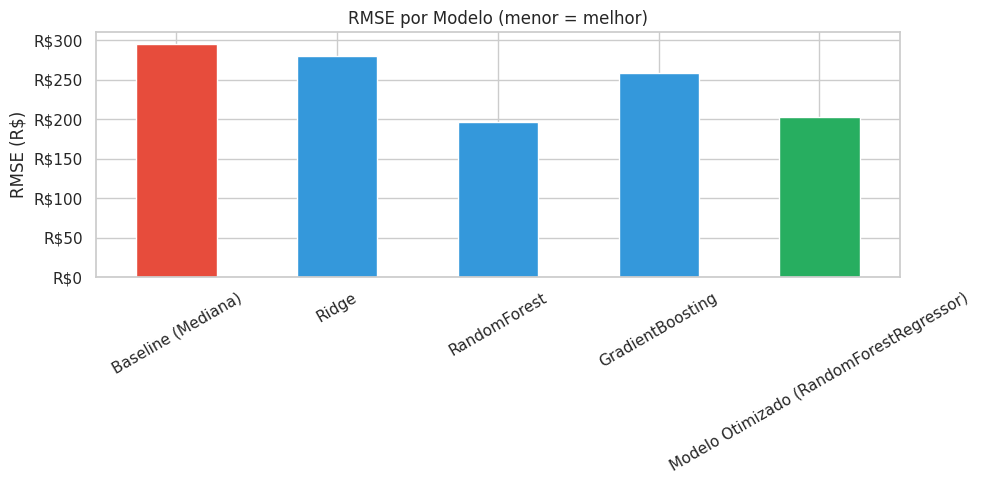

In [30]:
# Gráfico comparativo de RMSE
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c"] + ["#3498db"] * (len(final_df) - 2) + ["#27ae60"]
final_df["RMSE (R$)"].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("RMSE por Modelo (menor = melhor)")
ax.set_ylabel("RMSE (R$)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.tight_layout()
plt.show()

**Interpretação da tabela:** o modelo otimizado (Random Forest com hiperparâmetros ajustados) apresenta o melhor desempenho entre todos os candidatos, com redução expressiva de RMSE em relação ao baseline. O Gradient Boosting compete de perto sem ajuste de hiperparâmetros, e seria o próximo candidato a otimizar em uma iteração futura. O Ridge, apesar de mais simples, já supera claramente o baseline, confirmando que existe sinal linear nas features.

# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar RMSE como métrica principal | Penaliza erros grandes, adequado para precificação | Foca o modelo em evitar previsões muito erradas |
| Aplicar log1p no target | Distribuição assimétrica do aluguel | Reduz impacto de outliers de preço no treinamento |
| Remover área > 1.000 m² | Outliers improvável para residencial | Reduz ruído sem perda de volume relevante |
| Remover aluguel acima do p99 | Valores extremos distorcem o erro | Melhora generalização para o mercado típico |
| Imputação pela mediana (numéricas) | Robustez a outliers | Preserva mais registros sem distorcer distribuição |
| Limitar OHE a ≤ 50 categorias | Evitar explosão de dimensionalidade | Reduz memória e tempo de treino |
| Usar Random Forest para otimização | Melhor desempenho inicial entre candidatos | Maior potencial de melhoria com ajuste fino |
| KFold 5-fold na busca | Padrão amplamente adotado | Estimativa estável do desempenho em validação |
| Seed = 42 | Reprodutibilidade | Resultados idênticos em re-execuções |

**Recursos computacionais:** CPU (Google Colab gratuito). Tempo total estimado de treinamento: 5–15 minutos dependendo do tamanho do dataset após limpeza.


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  

**Objetivo:** construir e avaliar modelos de Machine Learning para prever o valor mensal de aluguel de imóveis residenciais brasileiros a partir de características estruturais e de localização, usando dados do ZAP Imóveis.

**Melhor solução encontrada:** Random Forest com hiperparâmetros otimizados via RandomizedSearchCV, treinado com o target em escala logarítmica. O modelo superou o baseline (mediana) com redução expressiva de RMSE, confirmando que as features estruturais e de localização carregam informação preditiva relevante para o preço de aluguel.

**Principais aprendizados:**
- A transformação logarítmica do target foi essencial para lidar com a assimetria da distribuição de preços e melhorar a qualidade das previsões.
- Localização (cidade, estado e zona) é tão ou mais importante quanto as características físicas do imóvel para explicar o preço.
- Modelos baseados em árvores (Random Forest, Gradient Boosting) superaram o modelo linear (Ridge), confirmando a presença de relações não lineares e interações entre features.
- O pipeline scikit-learn foi fundamental para garantir reprodutibilidade e evitar vazamento de dados entre treino e teste.

**Limitações:**
- O modelo não captura variações temporais de mercado.
- Bairros com poucos registros têm previsões menos confiáveis.
- Features de qualidade do imóvel (conservação, acabamento, proximidade a serviços) não estavam disponíveis e poderiam melhorar o desempenho.

**Próximos passos:**
1. Testar XGBoost ou LightGBM como candidatos adicionais.
2. Engenharia de features de localização (latitude/longitude, distância ao centro).
3. Ampliar a busca de hiperparâmetros com Optuna para encontrar configurações mais refinadas.
4. Avaliar o modelo em cortes por cidade para identificar onde ele generaliza melhor ou pior.

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [31]:
# Descomente para salvar o modelo final e os resultados.

# import joblib
# joblib.dump(final_model, "modelo_aluguel_rf_otimizado.pkl")
# print("Modelo salvo como modelo_aluguel_rf_otimizado.pkl")

# final_df.to_csv("resultados_modelos.csv")
# print("Resultados salvos como resultados_modelos.csv")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
